In [1]:
import numpy as np
import pandas as pd

In [2]:
import zipfile
with zipfile.ZipFile('spam.zip', 'r') as zip_ref:
    zip_ref.extractall('.')
    print(zip_ref.namelist())

['SMSSpamCollection', 'readme']


In [3]:
import pandas as pd

df = pd.read_csv(
    'SMSSpamCollection',
    sep='\t',
    header=None,
    names=['label', 'message']
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.to_csv('spam.csv', index=False)
print("spam.csv created successfully!")

spam.csv created successfully!


In [5]:
df = pd.read_csv('spam.csv')

In [6]:
df.sample(5)

,label,message
4360,ham,Ü only send me the contents page...
2728,ham,Whatsup there. Dont u want to sleep
981,ham,If he started searching he will get job in few...
5322,ham,"Thanks, I'll keep that in mind"
809,ham,I am taking half day leave bec i am not well


In [7]:
df.shape

(5572, 2)

In [8]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evalution
# 6. Improvement
# 7. Website 
# 8. Deploy

1. Data Cleaning

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [11]:
encoder.fit_transform(df['label'])

array([0, 0, 1, ..., 0, 0, 0])

In [12]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
#misssing value
df.isnull().sum()

label      0
message    0
dtype: int64

In [14]:
#check for duplicate values
df.duplicated().sum()

np.int64(403)

In [15]:
#remove duplicates
df.drop_duplicates(keep='first')

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [16]:
df = df.drop_duplicates(keep='first')

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(5169, 2)

2.EDA

In [19]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

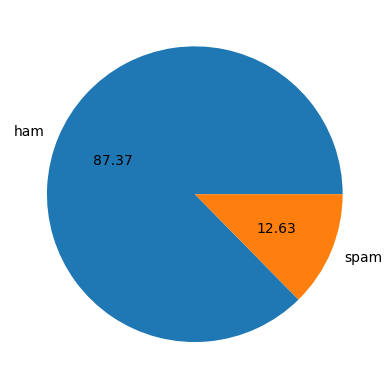

In [20]:
import matplotlib.pyplot as plt
plt.pie(df['label'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

In [21]:
#Data is imbalanced

In [22]:
!pip install nltk

In [23]:
import nltk

In [24]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\milib\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [25]:
df['message'].apply(len)

0       111
1        29
2       155
3        49
4        61
       ... 
5567    160
5568     36
5569     57
5570    125
5571     26
Name: message, Length: 5169, dtype: int64

In [26]:
df.loc[:,'num_characters'] = df['message'].apply(len)

In [27]:
df.head()

,label,message,num_characters
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [28]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\milib\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\milib\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [29]:
df['message'].apply(lambda x: nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568      [Will, ü, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: message, Length: 5169, dtype: object

In [30]:
df['message'].apply(lambda x:len(nltk.word_tokenize(x)))

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: message, Length: 5169, dtype: int64

In [31]:
df['num_words'] = df['message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [32]:
df.head()

,label,message,num_characters,num_words
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15


In [33]:
df['message'].apply(lambda x:nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568               [Will ü b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: message, Length: 5169, dtype: object

In [34]:
df['message'].apply(lambda x:len(nltk.sent_tokenize(x)))

0       2
1       2
2       2
3       1
4       1
       ..
5567    4
5568    1
5569    2
5570    1
5571    2
Name: message, Length: 5169, dtype: int64

In [35]:
df['num_sentenses'] = df['message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [36]:
df.head()

,label,message,num_characters,num_words,num_sentenses
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [37]:
df[['num_characters', 'num_words', 'num_sentenses']].describe()

,num_characters,num_words,num_sentenses
count,5169.000000,5169.000000,5169.000000
mean,79.344554,18.593538,1.974076
std,58.437457,13.402779,1.458967
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,119.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [38]:
#HAM
df[df['label'] == 'ham'][['num_characters', 'num_words', 'num_sentenses']].describe()

,num_characters,num_words,num_sentenses
count,4516.000000,4516.000000,4516.000000
mean,70.905890,17.267715,1.827724
std,56.715046,13.588065,1.394338
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [39]:
#SPAM
df[df['label'] == 'spam'][['num_characters', 'num_words', 'num_sentenses']].describe()

,num_characters,num_words,num_sentenses
count,653.000000,653.000000,653.000000
mean,137.704441,27.762634,2.986217
std,29.821348,6.993008,1.494815
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


In [40]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

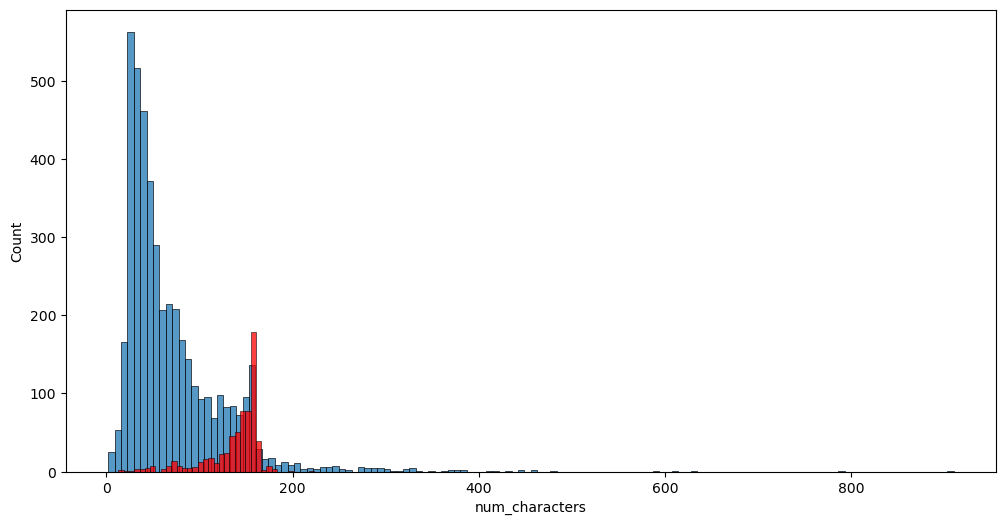

In [41]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['label'] == 'ham']['num_characters'])
sns.histplot(df[df['label'] == 'spam']['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

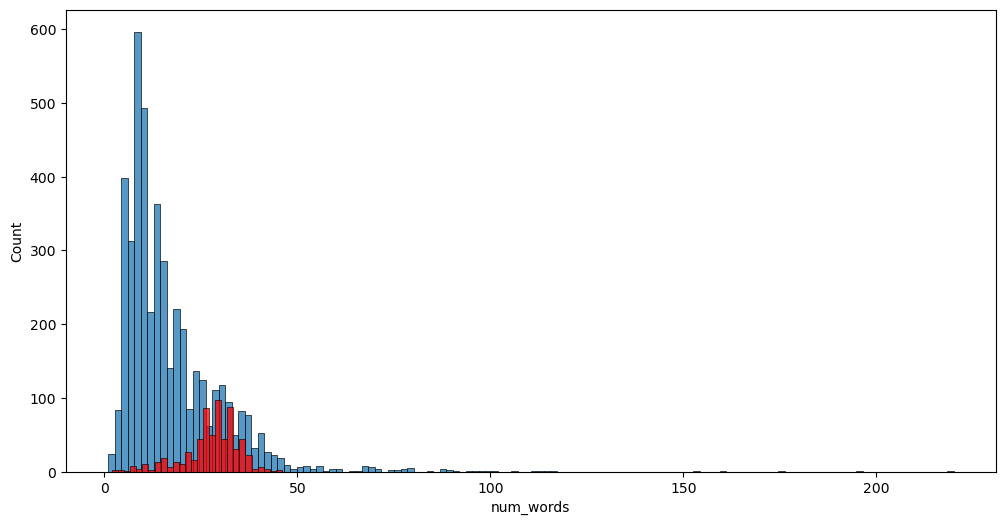

In [42]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['label'] == 'ham']['num_words'])
sns.histplot(df[df['label'] == 'spam']['num_words'], color='red')

<Axes: xlabel='num_sentenses', ylabel='Count'>

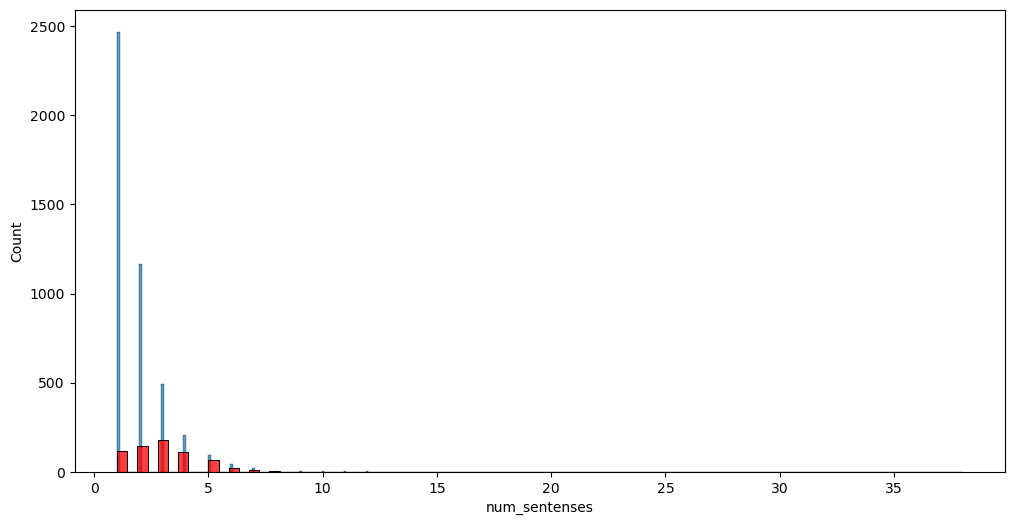

In [43]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['label'] == 'ham']['num_sentenses'])
sns.histplot(df[df['label'] == 'spam']['num_sentenses'], color='red')

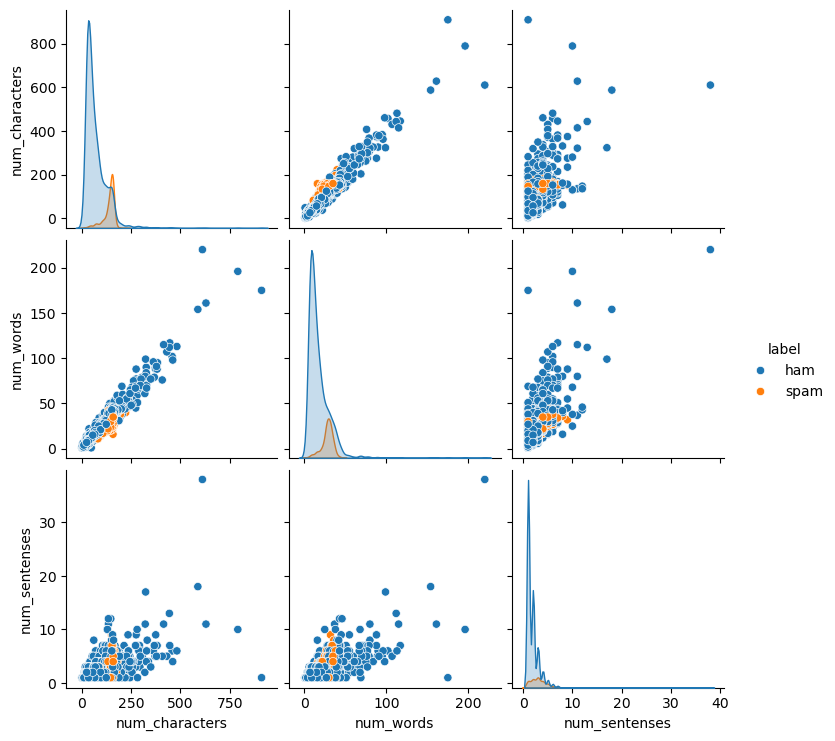

In [44]:
sns.pairplot(df, hue='label')

<Axes: >

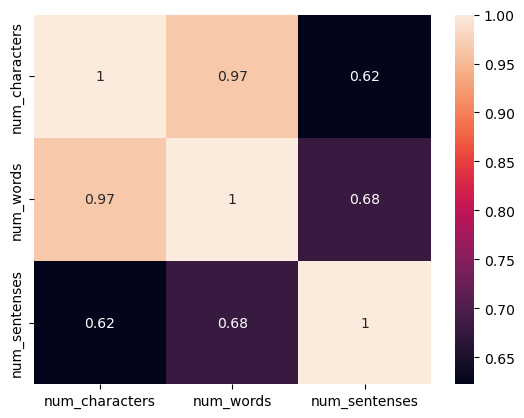

In [45]:
sns.heatmap(
    df[['num_characters', 'num_words', 'num_sentenses']].corr(),
    annot=True
)

In [46]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\milib\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\milib\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [47]:
def transform_message(message):
    message = message.lower()
    message = nltk.word_tokenize(message)
    return message

In [48]:
transform_message('Hi how are you')

['hi', 'how', 'are', 'you']

In [49]:
#removing special characters
def transform_message(message):
    message = message.lower()
    message = nltk.word_tokenize(message)
    y = []
    for i in message:
        if i.isalnum():
           y.append(i)
    return y

In [50]:
transform_message('Hi how are you  ## %%')

['hi', 'how', 'are', 'you']

In [51]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\milib\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [52]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [53]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [54]:
#removing punctuation
def transform_message(message):
    message = message.lower()
    message = nltk.word_tokenize(message)
    
    y = []
    
    for i in message:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    return y

In [55]:
transform_message('Hlw, how are you Binanda?')

['hlw', 'binanda']

In [56]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [57]:
def transform_message(message):
    message = message.lower()
    message = nltk.word_tokenize(message)

    y = []

    for i in message:
        y.append(ps.stem(i))

    return " ".join(y)

In [58]:
transform_message('I loved the YT lectures on Machine Learning. How about you?')

'i love the yt lectur on machin learn . how about you ?'

In [59]:
df['message'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [60]:
#testing
transform_message('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go until jurong point , crazi .. avail onli in bugi n great world la e buffet ... cine there got amor wat ...'

In [61]:
df['message'].apply(transform_message)

0       go until jurong point , crazi .. avail onli in...
1                           ok lar ... joke wif u oni ...
2       free entri in 2 a wkli comp to win fa cup fina...
3       u dun say so earli hor ... u c alreadi then sa...
4       nah i do n't think he goe to usf , he live aro...
                              ...                        
5567    thi is the 2nd time we have tri 2 contact u. u...
5568                    will ü b go to esplanad fr home ?
5569    piti , * wa in mood for that . so ... ani othe...
5570    the guy did some bitch but i act like i 'd be ...
5571                            rofl . it true to it name
Name: message, Length: 5169, dtype: object

In [62]:
#adding in new column
df['transform_message'] = df['message'].apply(transform_message)

In [63]:
df.head()

,label,message,num_characters,num_words,num_sentenses,transform_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2,"go until jurong point , crazi .. avail onli in..."
1,ham,Ok lar... Joking wif u oni...,29,8,2,ok lar ... joke wif u oni ...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri in 2 a wkli comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,49,13,1,u dun say so earli hor ... u c alreadi then sa...
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"nah i do n't think he goe to usf , he live aro..."


In [64]:
import wordcloud

In [65]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [66]:
df.columns

Index(['label', 'message', 'num_characters', 'num_words', 'num_sentenses',
       'transform_message'],
      dtype='object')

In [67]:
wc.generate(
    df[df['label'] == 'spam']['transform_message'].str.cat(sep=" ")
)

In [68]:
spam_wc = wc.generate(
    df[df['label'] == 'spam']['transform_message'].str.cat(sep=" ")
)

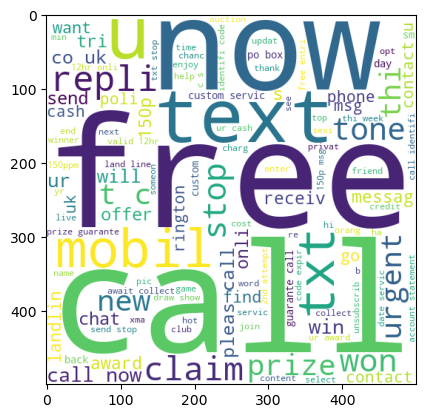

In [69]:
plt.imshow(spam_wc)

In [70]:
ham_wc = wc.generate(
    df[df['label'] == 'ham']['transform_message'].str.cat(sep=" ")
)

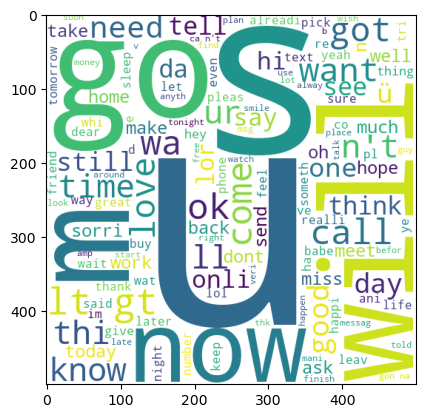

In [71]:
plt.imshow(ham_wc)

In [72]:
df[df['label'] == 'spam']

,label,message,num_characters,num_words,num_sentenses,transform_message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri in 2 a wkli comp to win fa cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...,147,39,4,freemsg hey there darl it 's been 3 week 's no...
8,spam,WINNER!! As a valued network customer you have...,157,32,5,winner ! ! as a valu network custom you have b...
9,spam,Had your mobile 11 months or more? U R entitle...,154,31,3,had your mobil 11 month or more ? u r entitl t...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po...",136,31,3,"six chanc to win cash ! from 100 to 20,000 pou..."
...,...,...,...,...,...,...
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...,90,18,3,want explicit sex in 30 sec ? ring 02073162414...
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,158,38,6,ask 3mobil if 0870 chatlin inclu in free min ....
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...,160,35,5,had your contract mobil 11 mnth ? latest motor...
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...,147,30,1,remind from o2 : to get 2.50 pound free call c...


In [73]:
#For Spam
spam_corpus = []
for msg in df[df['label'] == 'spam']['transform_message'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [74]:
len(spam_corpus)

18045

In [75]:
from collections import Counter
Counter(spam_corpus)

Counter({'.': 784,
         'to': 598,
         '!': 456,
         'a': 332,
         'call': 320,
         ',': 306,
         'you': 268,
         'your': 252,
         'free': 191,
         'for': 184,
         'the': 183,
         'now': 164,
         '&': 160,
         '?': 160,
         'or': 157,
         '2': 155,
         ':': 150,
         'is': 144,
         'txt': 141,
         'text': 122,
         'on': 122,
         'from': 122,
         'u': 120,
         'ur': 119,
         'have': 116,
         'mobil': 114,
         '*': 108,
         'stop': 108,
         'and': 104,
         'repli': 103,
         'claim': 98,
         '4': 97,
         'with': 94,
         'prize': 82,
         'thi': 82,
         'of': 81,
         'our': 77,
         'get': 74,
         'are': 69,
         'just': 68,
         'onli': 66,
         'new': 64,
         'servic': 64,
         'tone': 63,
         'in': 62,
         'send': 61,
         "'s": 59,
         'won': 59,
         't': 58,

In [76]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('.', 784),
 ('to', 598),
 ('!', 456),
 ('a', 332),
 ('call', 320),
 (',', 306),
 ('you', 268),
 ('your', 252),
 ('free', 191),
 ('for', 184),
 ('the', 183),
 ('now', 164),
 ('&', 160),
 ('?', 160),
 ('or', 157),
 ('2', 155),
 (':', 150),
 ('is', 144),
 ('txt', 141),
 ('text', 122),
 ('on', 122),
 ('from', 122),
 ('u', 120),
 ('ur', 119),
 ('have', 116),
 ('mobil', 114),
 ('*', 108),
 ('stop', 108),
 ('and', 104),
 ('repli', 103)]

In [77]:
from collections import Counter
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,.,784
1,to,598
2,!,456
3,a,332
4,call,320
5,",",306
6,you,268
7,your,252
8,free,191
9,for,184


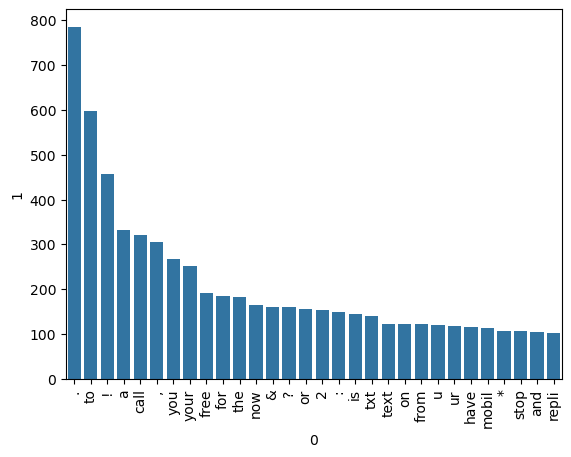

In [78]:
from collections import Counter

spam_df = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=spam_df[0], y=spam_df[1])
plt.xticks(rotation='vertical')
plt.show()

In [79]:
ham_corpus = []
for msg in df[df['label'] == 'ham']['transform_message'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [80]:
len(ham_corpus)

77909

In [81]:
from collections import Counter
Counter(ham_corpus)

Counter({'.': 3534,
         'i': 2714,
         'you': 1871,
         'to': 1481,
         ',': 1388,
         '?': 1331,
         '...': 1084,
         'the': 1060,
         'a': 969,
         'u': 897,
         'it': 853,
         'and': 824,
         '!': 802,
         'in': 757,
         'me': 736,
         ';': 679,
         'my': 677,
         'is': 663,
         '&': 658,
         'that': 574,
         'do': 555,
         '..': 538,
         'have': 484,
         'for': 481,
         ':': 481,
         'of': 478,
         'but': 418,
         "'s": 415,
         'so': 413,
         'go': 407,
         'are': 399,
         'not': 395,
         ')': 392,
         'your': 389,
         "'m": 371,
         'on': 371,
         'can': 368,
         'at': 361,
         'be': 358,
         'get': 351,
         "n't": 341,
         'we': 340,
         'will': 319,
         'if': 319,
         'how': 310,
         '2': 288,
         'gt': 288,
         'lt': 287,
         'up': 286,
    

In [82]:
from collections import Counter
pd.DataFrame(Counter(ham_corpus).most_common(30))

,0,1
0,.,3534
1,i,2714
2,you,1871
3,to,1481
4,",",1388
5,?,1331
6,...,1084
7,the,1060
8,a,969
9,u,897


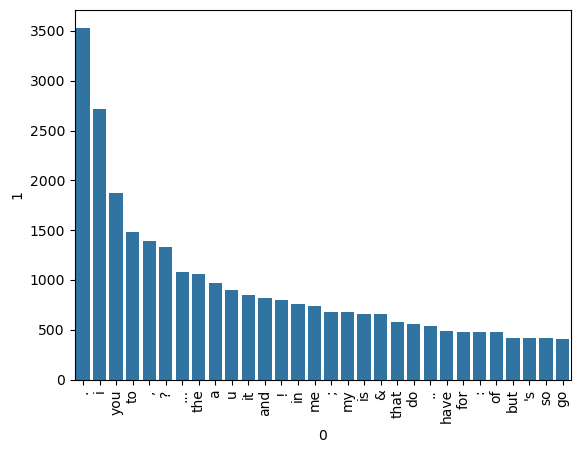

In [83]:
from collections import Counter

ham_df = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=ham_df[0], y=ham_df[1])
plt.xticks(rotation='vertical')
plt.show()

Model Building

In [84]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [85]:
X = cv.fit_transform(df['transform_message']).toarray()

In [86]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [87]:
#appending the num_character col to X
X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [88]:
X

array([[  0,   0,   0, ...,   0,   0, 111],
       [  0,   0,   0, ...,   0,   0,  29],
       [  0,   0,   0, ...,   0,   0, 155],
       ...,
       [  0,   0,   0, ...,   0,   0,  57],
       [  0,   0,   0, ...,   0,   0, 125],
       [  0,   0,   0, ...,   0,   0,  26]])

In [89]:
X.shape

(5169, 7455)

In [90]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

In [91]:
print(df['label'].head())

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


In [92]:
y = df['label'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [93]:
from sklearn.model_selection import train_test_split

In [94]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [95]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [96]:
gnb= GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [97]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8752417794970987
[[798 110]
 [ 19 107]]
0.4930875576036866


In [98]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9806576402321083
[[904   4]
 [ 16 110]]
0.9649122807017544


In [99]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9729206963249516
[[904   4]
 [ 24 102]]
0.9622641509433962


In [100]:
#Repeating the same for better precesionscore by adding tfidvectorizer
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [101]:
X = tfidf.fit_transform(df['transform_message']).toarray()

In [102]:
X.shape

(5169, 7454)

In [103]:
y = df['label'].values

In [104]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [105]:
from sklearn.model_selection import train_test_split

In [106]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [107]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [108]:
gnb= GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [109]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8733075435203095
[[798 110]
 [ 21 105]]
0.4883720930232558


In [110]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9729206963249516
[[904   4]
 [ 24 102]]
0.9622641509433962


In [111]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9545454545454546
[[908   0]
 [ 47  79]]
1.0


In [112]:
!pip install xgboost

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [114]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [115]:
clfs = {
    'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [116]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [117]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9777562862669246, 0.9904761904761905)

In [118]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():

    current_accuracy, current_precision = train_classifier(
        clf, X_train, y_train, X_test, y_test
    )

    print("For", name)
    print("Accuracy -", current_accuracy)
    print("Precision -", current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC
Accuracy - 0.9777562862669246
Precision - 0.9904761904761905
For KN
Accuracy - 0.9119922630560928
Precision - 1.0
For NB
Accuracy - 0.9545454545454546
Precision - 1.0
For DT
Accuracy - 0.9458413926499033
Precision - 0.9375
For LR
Accuracy - 0.9593810444874274
Precision - 0.9666666666666667
For RF
Accuracy - 0.9700193423597679
Precision - 0.9896907216494846
For AdaBoost
Accuracy - 0.9497098646034816
Precision - 0.9302325581395349
For BgC
Accuracy - 0.9671179883945842
Precision - 0.9423076923076923
For ETC
Accuracy - 0.9738878143133463
Precision - 1.0
For GBDT
Accuracy - 0.9593810444874274
Precision - 0.9666666666666667
For xgb
Accuracy - 0.9748549323017408
Precision - 0.9629629629629629


In [119]:
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

In [120]:
performance_df

,Algorithm,Accuracy,Precision
0,SVC,0.977756,0.990476
1,KN,0.911992,1.000000
2,NB,0.954545,1.000000
3,DT,0.945841,0.937500
4,LR,0.959381,0.966667
5,RF,0.970019,0.989691
6,AdaBoost,0.949710,0.930233
7,BgC,0.967118,0.942308
8,ETC,0.973888,1.000000
9,GBDT,0.959381,0.966667


In [121]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [122]:
performance_df1

,Algorithm,variable,value
0,SVC,Accuracy,0.977756
1,KN,Accuracy,0.911992
2,NB,Accuracy,0.954545
3,DT,Accuracy,0.945841
4,LR,Accuracy,0.959381
5,RF,Accuracy,0.970019
6,AdaBoost,Accuracy,0.949710
7,BgC,Accuracy,0.967118
8,ETC,Accuracy,0.973888
9,GBDT,Accuracy,0.959381


In [123]:
#In precision order
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [124]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.911992,1.000000
2,NB,0.954545,1.000000
8,ETC,0.973888,1.000000
0,SVC,0.977756,0.990476
5,RF,0.970019,0.989691
9,GBDT,0.959381,0.966667
4,LR,0.959381,0.966667
10,xgb,0.974855,0.962963
7,BgC,0.967118,0.942308
3,DT,0.945841,0.937500


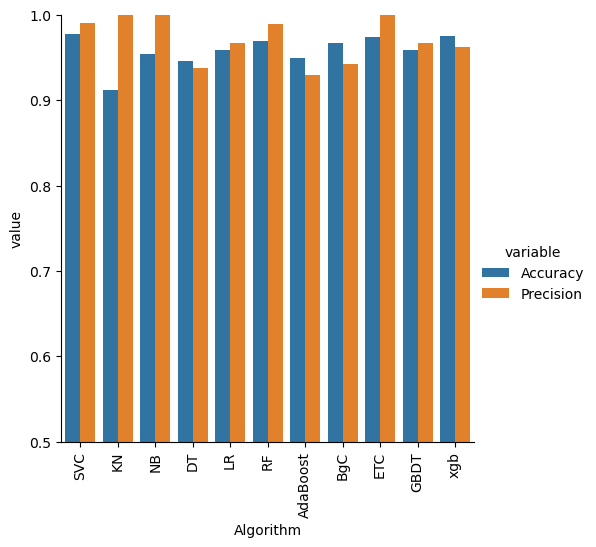

In [125]:
sns.catplot(x = 'Algorithm', y='value',
            hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [126]:
#Model improve
#1. Change the max_features parameter of TfIdf

In [127]:
temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_max_ft_3000': accuracy_scores,
    'Precision_max_ft_3000': precision_scores
})

In [128]:
performance_df = performance_df.merge(temp_df, on='Algorithm')

In [129]:
performance_df

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,0.911992,1.000000,0.911992,1.000000
1,NB,0.954545,1.000000,0.954545,1.000000
2,ETC,0.973888,1.000000,0.973888,1.000000
3,SVC,0.977756,0.990476,0.977756,0.990476
4,RF,0.970019,0.989691,0.970019,0.989691
5,GBDT,0.959381,0.966667,0.959381,0.966667
6,LR,0.959381,0.966667,0.959381,0.966667
7,xgb,0.974855,0.962963,0.974855,0.962963
8,BgC,0.967118,0.942308,0.967118,0.942308
9,DT,0.945841,0.937500,0.945841,0.937500


In [130]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))